In [1]:
# import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import tensorflow
import tensorflow as tf

In [3]:
import numpy as np
import random

def set_seed(seed):
    # set seed across 3
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

In [4]:
# load_data
train_ds = tf.keras.utils.image_dataset_from_directory(
           "/content/drive/MyDrive/ASL_Project/ASL_Gestures_36_Classes/train",
           labels="inferred",
           label_mode="int",
           validation_split=0.1,
           subset='training',
           image_size=(128, 128),
           seed=42,
           batch_size=16)

val_ds =  tf.keras.utils.image_dataset_from_directory(
          "/content/drive/MyDrive/ASL_Project/ASL_Gestures_36_Classes/train",
          labels="inferred",
          label_mode="int",
          validation_split=0.1,
          subset='validation',
          image_size=(128, 128),
          seed=42,
          batch_size=16)

Found 2011 files belonging to 36 classes.
Using 1810 files for training.
Found 2011 files belonging to 36 classes.
Using 201 files for validation.


In [5]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [6]:
for image_batch, label_batch in train_ds.take(1):
    print(f"Batch Shape {image_batch.shape}")
    print(f"Image Shape {image_batch[0].shape}")
    print(f"Label Shape {label_batch.shape}")

Batch Shape (16, 128, 128, 3)
Image Shape (128, 128, 3)
Label Shape (16,)


In [7]:
label_batch[0] # loss used categorical cross entropy as ohe

<tf.Tensor: shape=(), dtype=int32, numpy=25>

In [8]:
image_batch[0]

<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)>

In [9]:
class_names = train_ds.class_names
print(class_names)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [10]:
index_to_class = {i: class_name for i, class_name in enumerate(class_names)}
print(index_to_class)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'a', 11: 'b', 12: 'c', 13: 'd', 14: 'e', 15: 'f', 16: 'g', 17: 'h', 18: 'i', 19: 'j', 20: 'k', 21: 'l', 22: 'm', 23: 'n', 24: 'o', 25: 'p', 26: 'q', 27: 'r', 28: 's', 29: 't', 30: 'u', 31: 'v', 32: 'w', 33: 'x', 34: 'y', 35: 'z'}


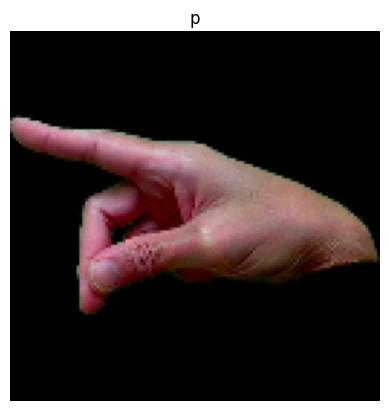

In [11]:
import matplotlib.pyplot as plt

def plot_image(img, label): # tf is optimized on both: CPU & GPU
    img = tf.reshape(img, (128, 128, 3))
    img = tf.cast(img, dtype=tf.uint8) # unsigned int 8 => [0, 256-1]
    plt.title(index_to_class[label.numpy()])
    plt.imshow(img)
    plt.axis('off')
    plt.show()

index = 0
img = image_batch[index]
label = label_batch[index]
plot_image(img, label)


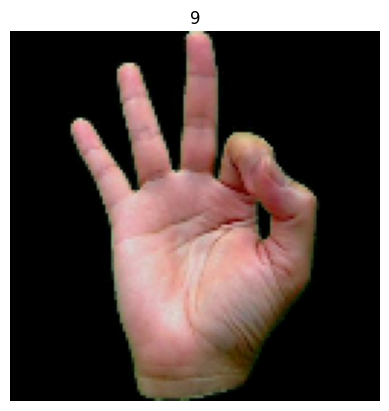

In [12]:
index = 15
img = image_batch[index]
label = label_batch[index]
plot_image(img, label)

## model archticture

In [13]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [14]:
# Input layer
img_input_ = Input(shape = (128, 128, 3))
scaled_input_ = Rescaling(1/255.0)(img_input_) # automitic scaling
flatten_input = Flatten()(scaled_input_)

# Layer one
hidden = Dense(128, kernel_initializer='he_normal')(flatten_input)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)


# Layer two
hidden = Dense(16334, kernel_initializer='he_normal')(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)


#### Output_Layer
output = Dense(36, activation='softmax', kernel_initializer='glorot_normal')(hidden)

model = Model(inputs=[img_input_], outputs=[output])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16334)          │     2,107,086 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16334)          │        65,336 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16334)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │       588,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,052,578 (34.53 MB)

 Trainable params: 9,019,654 (34.41 MB)

 Non-trainable params: 32,924 (128.61 KB)

## copile model

In [15]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## fit model

In [16]:
history = model.fit(train_ds, validation_data = val_ds, shuffle=True, epochs=20)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 415s 4s/step - accuracy: 0.5961 - loss: 2.8343 - val_accuracy: 0.6667 - val_loss: 3.7968
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7994 - loss: 1.5332 - val_accuracy: 0.6915 - val_loss: 3.2287
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8492 - loss: 1.0588 - val_accuracy: 0.8109 - val_loss: 1.8690
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8602 - loss: 1.1660 - val_accuracy: 0.7512 - val_loss: 4.1283
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8757 - loss: 1.1099 - val_accuracy: 0.7960 - val_loss: 2.6063
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9144 - loss: 0.8206 - val_accuracy: 0.8756 - val_loss: 1.5563
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9326 - loss: 0.5941 - val_accuracy: 0.9154 - val_loss: 1.3881
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9519 - loss: 0.3023 - val_accu

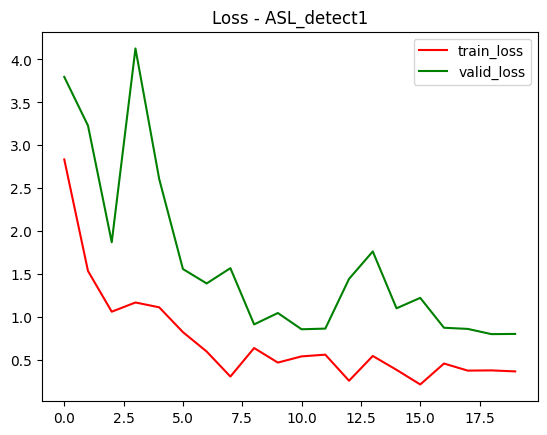

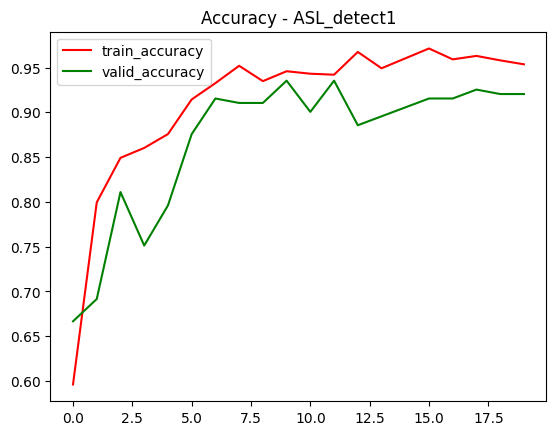

In [17]:
def plot_loss_acc(history, model_name='model_1'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='ASL_detect1')

when use simpler model to avoid over fit

In [18]:
#input layer
img_input_ = Input(shape = (128, 128, 3))
#input_ = Resizing(128, 128)(img_input_) #manule scaling
scaled_input_ = Rescaling(1/255.0)(img_input_) # automitic scaling
flatten_input = Flatten()(scaled_input_)

#layer one
hidden = Dense(2000, kernel_initializer='he_normal')(flatten_input)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
# hidden = Dropout(0.1)(hidden) # to avoid overfitting

#### Output_Layer
output = Dense(36, activation='softmax', kernel_initializer='glorot_normal')(hidden)

model = Model(inputs=[img_input_], outputs=[output])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2000)           │    98,306,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2000)           │         8,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 36)             │        72,036 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,386,036 (375.31 MB)

 Trainable params: 98,382,036 (375.30 MB)

 Non-trainable params: 4,000 (15.62 KB)

In [19]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(train_ds, validation_data = val_ds, shuffle=True, epochs=10)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7298 - loss: 1.0698 - val_accuracy: 0.7861 - val_loss: 0.8219
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9215 - loss: 0.2603 - val_accuracy: 0.8706 - val_loss: 0.4296
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9547 - loss: 0.1350 - val_accuracy: 0.8905 - val_loss: 0.4122
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9580 - loss: 0.1485 - val_accuracy: 0.9453 - val_loss: 0.1872
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9608 - loss: 0.1294 - val_accuracy: 0.9254 - val_loss: 0.2358
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9867 - loss: 0.0484 - val_accuracy: 0.9502 - val_loss: 0.1336
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9917 - loss: 0.0283 - val_accuracy: 0.9552 - val_loss: 0.1663
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9785 - loss: 0.0734 - val_accu

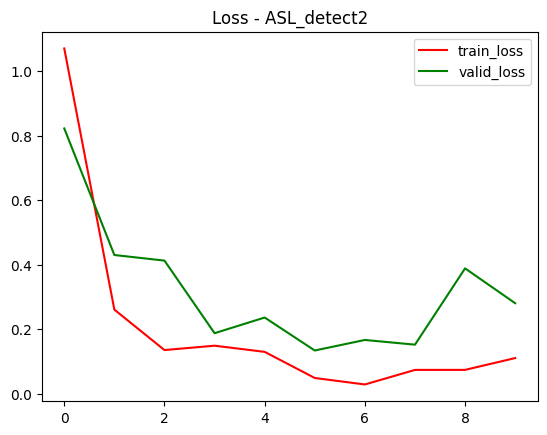

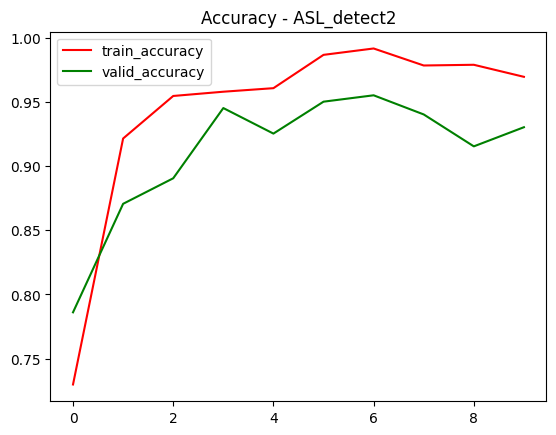

In [21]:
def plot_loss_acc(history, model_name='model_1'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='ASL_detect2')

In [23]:
# load test data

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/ASL_Project/ASL_Gestures_36_Classes/test",
    labels = "inferred",
    label_mode = "int",
    image_size = (128, 128),
    batch_size = 16,
    shuffle = True
)

Found 504 files belonging to 36 classes.


In [24]:
# our first FC Model
model.evaluate(test_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.9246 - loss: 0.3534


[0.3534369468688965, 0.9246031641960144]

# By DropOut

In [25]:
# Input layer
img_input_ = Input(shape=(128, 128, 3))
scaled_input_ = Rescaling(1/255.0)(img_input_) # automitic scaling
flatten_input = Flatten()(scaled_input_)

# Hidden layer
hidden = Dense(1000, kernel_initializer='he_normal')(flatten_input)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Dropout(0.1)(hidden) # to avoid overfitting

# Output layer
output = Dense(36, activation='softmax', kernel_initializer='glorot_normal')(hidden)

model = Model(inputs=[img_input_], outputs=[output])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │    49,153,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 36)             │        36,036 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,193,036 (187.66 MB)

 Trainable params: 49,191,036 (187.65 MB)

 Non-trainable params: 2,000 (7.81 KB)

In [26]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
history = model.fit(train_ds, validation_data=val_ds, shuffle=True, epochs=20)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.7514 - loss: 0.9079 - val_accuracy: 0.8408 - val_loss: 0.5364
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9569 - loss: 0.1690 - val_accuracy: 0.8955 - val_loss: 0.3482
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9779 - loss: 0.0942 - val_accuracy: 0.9303 - val_loss: 0.2465
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9851 - loss: 0.0702 - val_accuracy: 0.9303 - val_loss: 0.2145
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9967 - loss: 0.0336 - val_accuracy: 0.9602 - val_loss: 0.1343
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9961 - loss: 0.0290 - val_accuracy: 0.9552 - val_loss: 0.1326
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9895 - loss: 0.0447 - val_accuracy: 0.9552 - val_loss: 0.1491
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9978 - loss: 0.0216 - val_accu

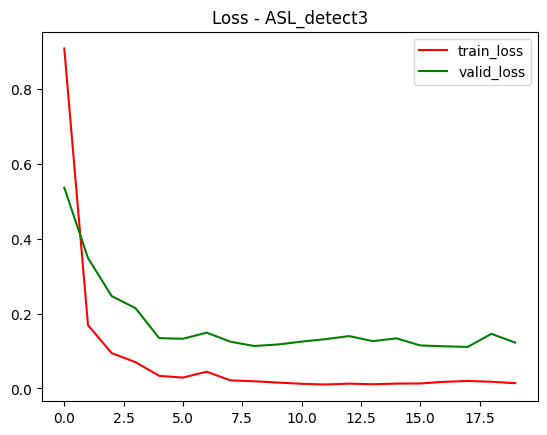

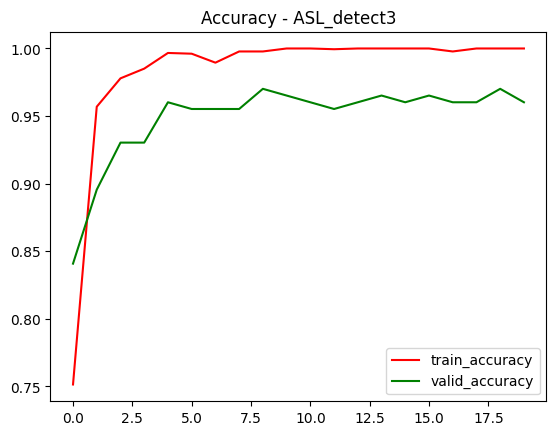

In [28]:
def plot_loss_acc(history, model_name='model_1'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='ASL_detect3')

In [29]:
# To Save Model
model.save("ASL_detect3.h5")

In [ ]:
# To Load Model
from tensorflow import keras
model = keras.models.load_model("ASL_detect3.h5")